# TensorGrad Demo

In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import time

In [ ]:
from tensorgrad.engine import Tensor
from tensorgrad.nn import Linear, VectorizedMLP

## Make Circle Demo

In [24]:
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# Convert y from [0, 1] to [-1, 1] for our SVM Max-Margin loss
y_circ = y_circ * 2 - 1

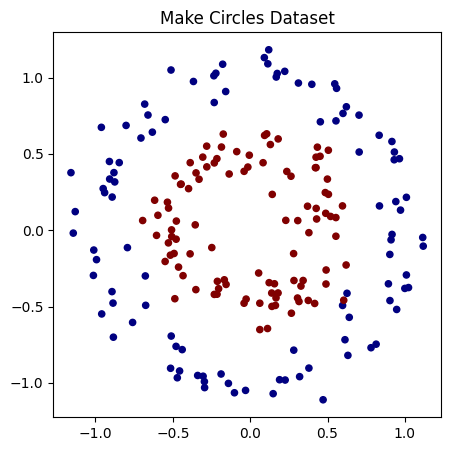

In [25]:
plt.figure(figsize=(5,5))
plt.scatter(X_circ[:,0], X_circ[:,1], c=y_circ, s=20, cmap='jet')
plt.title("Make Circles Dataset")
plt.show()

# Convert to Tensors
X_batch_circ = Tensor(X_circ, label='X_batch_circ')
y_batch_circ = Tensor(y_circ.reshape(-1, 1), label='y_batch_circ')

In [26]:
model_circ = VectorizedMLP(2, [16, 16, 1])
print(model_circ)
print("num of params: ", len(model_circ.parameters()))

VectorizedMLP(activation='relu') of [Linear(in=2, out=16), Linear(in=16, out=16), Linear(in=16, out=1)]
num of params:  6


In [27]:
epochs = 150
learning_rate = 1.0

In [28]:
for k in range(epochs):
    
    # forward pass
    scores = model_circ(X_batch_circ)
    
    # compute loss
    margin = (y_batch_circ * scores * -1.0) + 1.0
    data_loss = margin.relu().sum() * (1.0 / 200.0)
    
    # l2 reg
    alpha = 1e-4
    reg_loss = Tensor(0.0)
    for p in model_circ.parameters():
        reg_loss += (p * p).sum()
    reg_loss = reg_loss * alpha
    
    total_loss = data_loss + reg_loss
    
    # calc accuracy
    predictions = (scores.data > 0) * 2 - 1
    accuracy = (predictions == y_batch_circ.data).mean()
    
    # zero grad
    for p in model_circ.parameters():
        p.grad = np.zeros_like(p.data)
        
    # backward pass
    total_loss.backward()
    
    # update grad
    lr = learning_rate - 0.9 * k / epochs
    for p in model_circ.parameters():
        p.data -= lr * p.grad
        
    if k % 10 == 0 or k == epochs - 1:
        print(f"Step {k:3d} | Loss: {total_loss.data.item():.4f} | Accuracy: {accuracy*100:.1f}%")

Step   0 | Loss: 1.0000 | Accuracy: 50.0%
Step  10 | Loss: 0.9975 | Accuracy: 58.0%
Step  20 | Loss: 0.9923 | Accuracy: 60.0%
Step  30 | Loss: 0.9772 | Accuracy: 62.5%
Step  40 | Loss: 0.9166 | Accuracy: 64.0%
Step  50 | Loss: 0.7049 | Accuracy: 68.5%
Step  60 | Loss: 0.6060 | Accuracy: 73.0%
Step  70 | Loss: 0.6876 | Accuracy: 69.0%
Step  80 | Loss: 0.4348 | Accuracy: 81.5%
Step  90 | Loss: 0.1923 | Accuracy: 93.5%
Step 100 | Loss: 0.0553 | Accuracy: 98.5%
Step 110 | Loss: 0.0499 | Accuracy: 98.5%
Step 120 | Loss: 0.0466 | Accuracy: 98.5%
Step 130 | Loss: 0.0448 | Accuracy: 98.5%
Step 140 | Loss: 0.0440 | Accuracy: 99.0%
Step 149 | Loss: 0.0436 | Accuracy: 99.0%


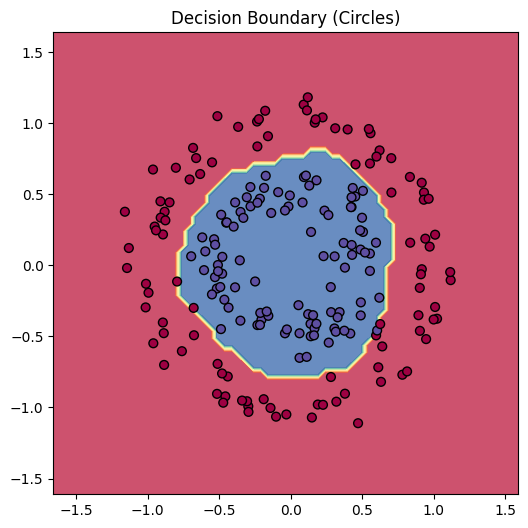

In [34]:
h = 0.05
x_min, x_max = X_circ[:, 0].min() - 0.5, X_circ[:, 0].max() + 0.5
y_min, y_max = X_circ[:, 1].min() - 0.5, X_circ[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Xmesh = np.c_[xx.ravel(), yy.ravel()]

scores = model_circ(Tensor(Xmesh))

Z = ((scores.data > 0) * 2 - 1).reshape(xx.shape)

fig = plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("Decision Boundary (Circles)")
plt.show()

## MNIST Digit Classfication Demo

In [3]:
print("Downloading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all, y_all = mnist.data, mnist.target.astype(int)

In [6]:
X_sub, X_test, y_sub, y_test = train_test_split(
    X_all, y_all, test_size=1000, stratify=y_all, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, train_size=4000, test_size=1000, stratify=y_sub, random_state=42
)

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

In [7]:
X_train_t = Tensor(X_train, label='X_train')
X_val_t = Tensor(X_val, label='X_val')

Training shapes: X=(4000, 784), y=(4000,)
Validation shapes: X=(1000, 784), y=(1000,)


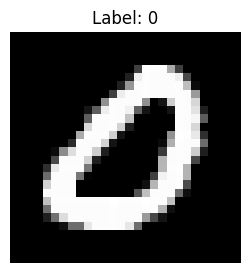

In [8]:
print(f"Training shapes: X={X_train_t.data.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val_t.data.shape}, y={y_val.shape}")

plt.figure(figsize=(3, 3))
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [9]:
model = VectorizedMLP(784, [64, 64, 10])
print(model)
print("num of params: ", len(model.parameters()))

VectorizedMLP(activation='relu') of [Linear(in=784, out=64), Linear(in=64, out=64), Linear(in=64, out=10)]
num of params:  6


In [10]:
epochs = 200
learning_rate = 0.78790
batch_size = X_train_t.data.shape[0]

In [11]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [12]:
start_time = time.time()

for k in range(epochs):
    # forward pass
    train_logits = model(X_train_t)
    
    # calc cross-entropy loss
    train_data_loss = train_logits.cross_entropy(y_train)
    
    # L2 regularization
    alpha = 0.00008
    reg_loss = Tensor(0.0)
    for p in model.parameters():
        reg_loss += (p * p).sum()
    reg_loss = reg_loss * alpha
    
    train_loss = train_data_loss + reg_loss
    
    train_preds = np.argmax(train_logits.data, axis=1)
    train_acc = (train_preds == y_train).mean()
    
    val_logits = model(X_val_t)
    
    val_loss = val_logits.cross_entropy(y_val)
    
    val_preds = np.argmax(val_logits.data, axis=1)
    val_acc = (val_preds == y_val).mean()
    
    history['train_loss'].append(train_loss.data.item())
    history['val_loss'].append(val_loss.data.item())
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # zero grad
    for p in model.parameters():
        p.grad = np.zeros_like(p.data)
        
    train_loss.backward()
    
    # grad descent
    lr = learning_rate - 0.4 * k / epochs
    for p in model.parameters():
        p.data -= lr * p.grad
        
    if k % 10 == 0 or k == epochs - 1:
        print(f"Step {k:3d} | Train Loss: {train_loss.data.item():.4f} | Val Loss: {val_loss.data.item():.4f} | Train Acc: {train_acc*100:.1f}% | Val Acc: {val_acc*100:.1f}%")

print(f"\nTraining Complete in {time.time() - start_time:.2f} seconds!")

Step   0 | Train Loss: 2.3529 | Val Loss: 2.3036 | Train Acc: 8.3% | Val Acc: 9.4%
Step  10 | Train Loss: 2.0418 | Val Loss: 1.9898 | Train Acc: 28.2% | Val Acc: 27.2%
Step  20 | Train Loss: 1.4386 | Val Loss: 1.3854 | Train Acc: 59.2% | Val Acc: 60.5%
Step  30 | Train Loss: 0.6485 | Val Loss: 0.6014 | Train Acc: 81.7% | Val Acc: 80.8%
Step  40 | Train Loss: 0.6411 | Val Loss: 0.6003 | Train Acc: 80.9% | Val Acc: 77.4%
Step  50 | Train Loss: 0.4457 | Val Loss: 0.4167 | Train Acc: 88.9% | Val Acc: 87.7%
Step  60 | Train Loss: 0.4583 | Val Loss: 0.4496 | Train Acc: 87.1% | Val Acc: 85.4%
Step  70 | Train Loss: 0.4871 | Val Loss: 0.4872 | Train Acc: 85.8% | Val Acc: 83.6%
Step  80 | Train Loss: 0.3005 | Val Loss: 0.3008 | Train Acc: 93.0% | Val Acc: 90.1%
Step  90 | Train Loss: 0.2724 | Val Loss: 0.2829 | Train Acc: 93.8% | Val Acc: 90.8%
Step 100 | Train Loss: 0.2520 | Val Loss: 0.2725 | Train Acc: 94.5% | Val Acc: 91.9%
Step 110 | Train Loss: 0.2357 | Val Loss: 0.2651 | Train Acc: 95.2%

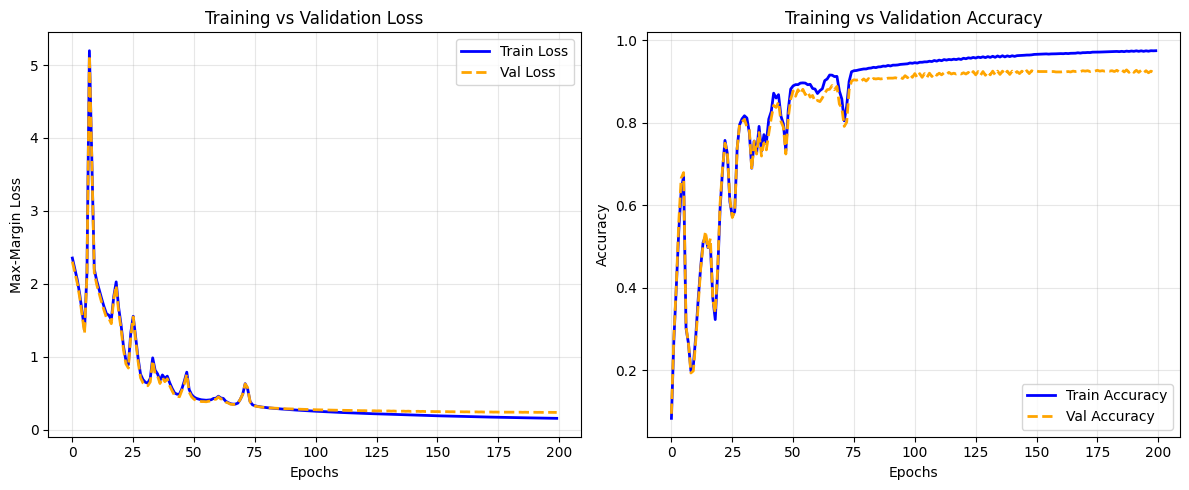

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title("Training vs Validation Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Max-Margin Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2, linestyle='--')
ax2.set_title("Training vs Validation Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
X_test_t = Tensor(X_test)

test_scores = model(X_test_t)

test_preds = np.argmax(test_scores.data, axis=1)

test_acc = (test_preds == y_test).mean()

print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

Final Test Accuracy: 90.90%



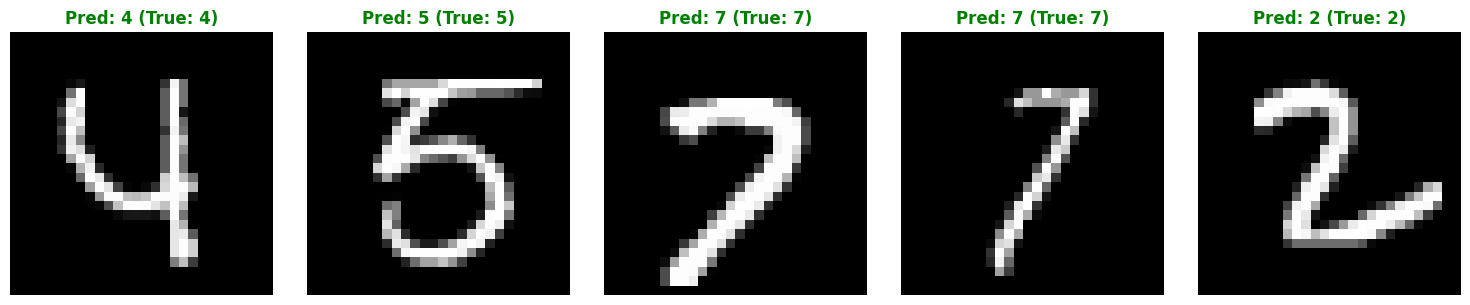

In [22]:
# pick 5 random indices from the Test set to visualize
num_samples = 5
indices = random.sample(range(X_test.shape[0]), num_samples)

sample_images = X_test[indices]
sample_labels = y_test[indices]

# run inference just on those 5 samples
inference_batch = Tensor(sample_images)
raw_scores = model(inference_batch)
multiclass_preds = np.argmax(raw_scores.data, axis=1)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    ax = axes[i]
    img = sample_images[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    
    pred_digit = multiclass_preds[i]
    true_digit = sample_labels[i]
    
    color = 'green' if pred_digit == true_digit else 'red'
    ax.set_title(f"Pred: {pred_digit} (True: {true_digit})", color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()